# 92 — Funding Rate Flip Strategy

**Hypothesis**: Deeply negative funding = overcrowded shorts. When funding starts rising from a deep low, shorts are unwinding → price bounces.

## Strategy
- **Resolution**: Hourly
- **Entry**: Funding rate goes deeply negative (< threshold) AND starts rising (funding > its N-bar MA)
- **Exit**: Funding turns positive (> +threshold) OR stop loss OR time stop
- **Risk**: High — funding can stay negative for weeks in bear markets
- **Period**: 2020-02-02 → present

In [1]:
import pandas as pd
import numpy as np
import vectorbt as vbt
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('.').resolve().parent
BL_HOURLY = PROJECT_ROOT / 'data' / 'bl' / 'hourly'
GN_HOURLY = PROJECT_ROOT / 'data' / 'glassnode' / 'hourly'

BACKTEST_START = '2020-02-02'
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/fester/Documents/bitcoin-lab-btc-data-pipeline


## 1. Data Loading

In [2]:
def load_parquet(path: Path) -> pd.Series:
    if not path.exists():
        print(f'WARNING: {path} not found')
        return pd.Series(dtype=float)
    df = pd.read_parquet(path)
    time_col = next((c for c in ['time', 'date', 'timestamp'] if c in df.columns), None)
    if time_col is None and isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index()
        time_col = df.columns[0]
    val_col = 'value' if 'value' in df.columns else next((c for c in df.columns if c not in ['time', 'date', 'timestamp']), None)
    s = df.set_index(time_col)[val_col].sort_index()
    s.index = pd.to_datetime(s.index)
    if s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    return s.astype(float)


price = load_parquet(BL_HOURLY / 'price.parquet').loc[BACKTEST_START:]
funding = load_parquet(GN_HOURLY / 'funding_rate.parquet')
liq_long = load_parquet(GN_HOURLY / 'liquidations_long.parquet')
liq_short = load_parquet(GN_HOURLY / 'liquidations_short.parquet')

idx = price.index
df = pd.DataFrame(index=idx)
df['price'] = price
df['funding'] = funding.reindex(idx, method='ffill')
df['liq_long'] = liq_long.reindex(idx, method='ffill')
df['liq_short'] = liq_short.reindex(idx, method='ffill')
df = df.dropna(subset=['price'])

print(f'Hourly bars: {len(df):,}')
print(f'Date range: {df.index[0]} → {df.index[-1]}')
print(f'Funding nulls: {df["funding"].isna().sum()}')
print(f'Funding range: {df["funding"].min():.6f} to {df["funding"].max():.6f}')

Hourly bars: 52,391
Date range: 2020-02-02 00:00:00 → 2026-01-30 11:00:00
Funding nulls: 0
Funding range: -0.003364 to 0.002034


## 2. Funding Rate Analysis

In [3]:
# Distribution
print('Funding Rate Distribution:')
print(df['funding'].describe())
print(f'\nPercentiles:')
for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    val = df['funding'].quantile(pct/100)
    print(f'  {pct:>3}th: {val:.6f}')

print(f'\nBars by funding level:')
for thresh in [-0.03, -0.02, -0.01, -0.005, 0, 0.005, 0.01, 0.02, 0.03]:
    n_below = (df['funding'] < thresh).sum()
    n_above = (df['funding'] > thresh).sum()
    print(f'  < {thresh:>+.3f}: {n_below:>5} ({n_below/len(df)*100:.1f}%)  |  > {thresh:>+.3f}: {n_above:>5} ({n_above/len(df)*100:.1f}%)')

Funding Rate Distribution:
count    52391.000000
mean         0.000090
std          0.000208
min         -0.003364
25%          0.000026
50%          0.000064
75%          0.000099
max          0.002034
Name: funding, dtype: float64

Percentiles:
    1th: -0.000250
    5th: -0.000062
   10th: -0.000018
   25th: 0.000026
   50th: 0.000064
   75th: 0.000099
   90th: 0.000212
   95th: 0.000393
   99th: 0.000948

Bars by funding level:
  < -0.030:     0 (0.0%)  |  > -0.030: 52391 (100.0%)
  < -0.020:     0 (0.0%)  |  > -0.020: 52391 (100.0%)
  < -0.010:     0 (0.0%)  |  > -0.010: 52391 (100.0%)
  < -0.005:     0 (0.0%)  |  > -0.005: 52391 (100.0%)
  < +0.000:  7477 (14.3%)  |  > +0.000: 44914 (85.7%)
  < +0.005: 52391 (100.0%)  |  > +0.005:     0 (0.0%)
  < +0.010: 52391 (100.0%)  |  > +0.010:     0 (0.0%)
  < +0.020: 52391 (100.0%)  |  > +0.020:     0 (0.0%)
  < +0.030: 52391 (100.0%)  |  > +0.030:     0 (0.0%)


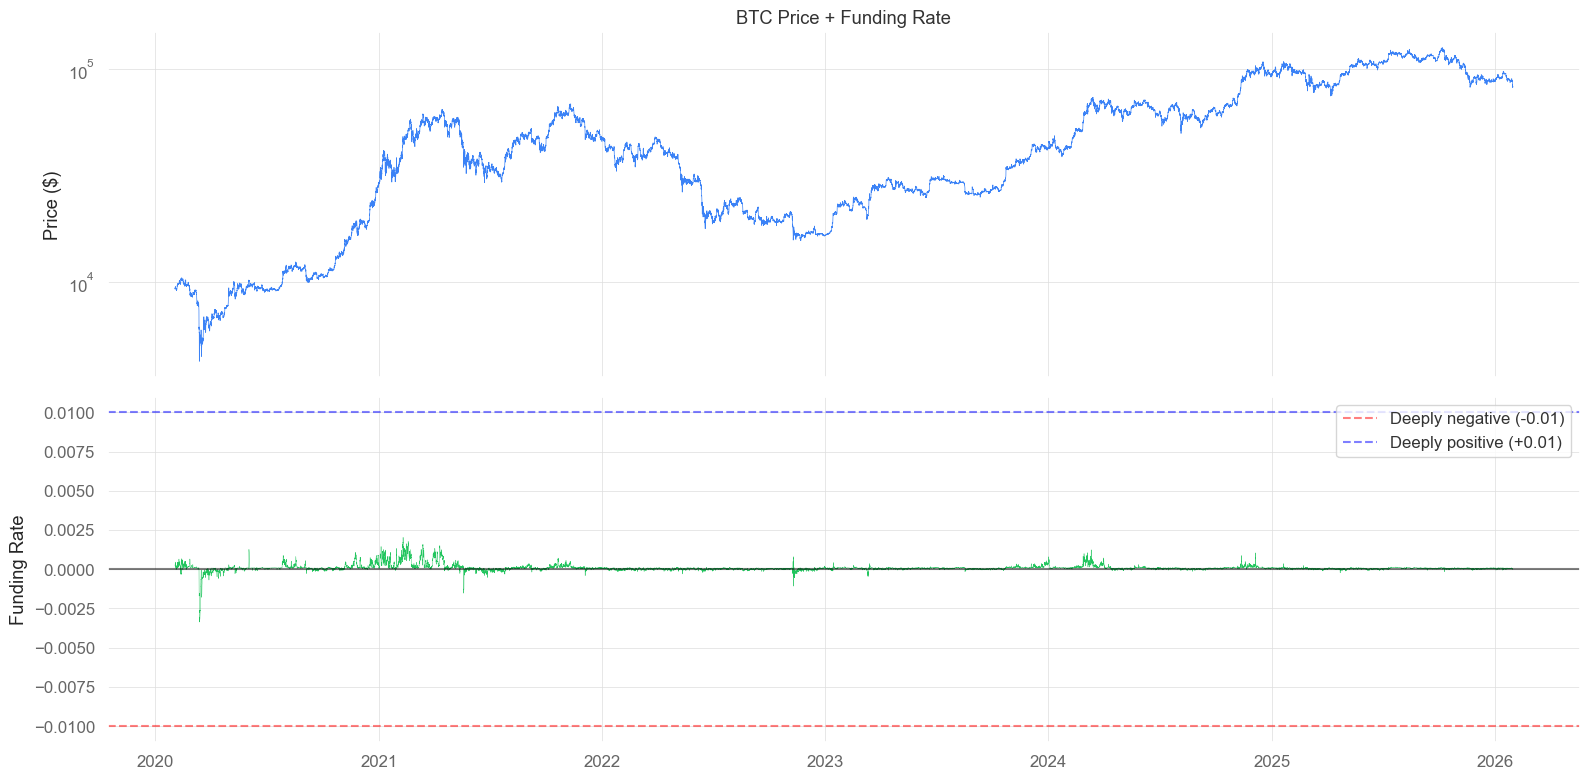

In [4]:
# Visualize funding rate + price
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df.index, df['price'], color='#3b82f6', linewidth=0.5)
axes[0].set_ylabel('Price ($)')
axes[0].set_title('BTC Price + Funding Rate')
axes[0].set_yscale('log')

axes[1].plot(df.index, df['funding'], color='#22c55e', linewidth=0.3)
axes[1].axhline(0, color='black', linestyle='-', alpha=0.5)
axes[1].axhline(-0.01, color='red', linestyle='--', alpha=0.5, label='Deeply negative (-0.01)')
axes[1].axhline(0.01, color='blue', linestyle='--', alpha=0.5, label='Deeply positive (+0.01)')
axes[1].set_ylabel('Funding Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Funding Rate Flip Signal Construction

"Flip" = funding was deeply negative, now crossing above its short-term MA (momentum turning up).

In [5]:
# Build flip signals with various parameters
for ma_len in [8, 12, 24]:
    df[f'funding_ma{ma_len}'] = df['funding'].rolling(ma_len, min_periods=1).mean()

# Forward returns after funding goes deeply negative
for hrs in [4, 12, 24, 48, 72, 168]:
    df[f'fwd_{hrs}h'] = df['price'].pct_change(hrs).shift(-hrs) * 100

print('Forward returns when funding < threshold:')
print('=' * 90)
horizons = [4, 12, 24, 48, 72, 168]
print(f'{"Condition":>30s}', end='')
for h in horizons:
    print(f'  |  {h:>5}h', end='')
print(f'  |  {"N":>5}')
print('-' * 90)

# Pure level signals
for thresh in [-0.03, -0.02, -0.01, -0.005]:
    mask = df['funding'] < thresh
    n = mask.sum()
    print(f'  funding < {thresh:>+.3f}           ', end='')
    for h in horizons:
        ret = df.loc[mask, f'fwd_{h}h'].mean()
        print(f'  |  {ret:>+5.2f}%', end='')
    print(f'  |  {n:>5}')

print()

# Flip signals: funding below threshold AND crossing above MA
for thresh in [-0.02, -0.01, -0.005]:
    for ma_len in [8, 12, 24]:
        mask = (df['funding'] < thresh) & (df['funding'] > df[f'funding_ma{ma_len}'])
        n = mask.sum()
        if n < 5:
            continue
        print(f'  f<{thresh:+.3f} & f>MA{ma_len:<2d}       ', end='')
        for h in horizons:
            ret = df.loc[mask, f'fwd_{h}h'].mean()
            print(f'  |  {ret:>+5.2f}%', end='')
        print(f'  |  {n:>5}')

Forward returns when funding < threshold:
                     Condition  |      4h  |     12h  |     24h  |     48h  |     72h  |    168h  |      N
------------------------------------------------------------------------------------------
  funding < -0.030             |   +nan%  |   +nan%  |   +nan%  |   +nan%  |   +nan%  |   +nan%  |      0
  funding < -0.020             |   +nan%  |   +nan%  |   +nan%  |   +nan%  |   +nan%  |   +nan%  |      0
  funding < -0.010             |   +nan%  |   +nan%  |   +nan%  |   +nan%  |   +nan%  |   +nan%  |      0
  funding < -0.005             |   +nan%  |   +nan%  |   +nan%  |   +nan%  |   +nan%  |   +nan%  |      0



## 4. VectorBT Backtest — Grid Search

Test:
- Entry: funding < threshold AND funding > MA (flip)
- Exit: funding > positive threshold OR stop loss

In [6]:
def run_funding_flip_backtest(df, neg_thresh, ma_len, pos_exit, sl_pct=None, tp_pct=None):
    """Backtest funding rate flip strategy.
    
    Entry: funding < neg_thresh AND funding > funding_MA (turning up from deep negative)
    Exit: funding > pos_exit OR stop/take-profit
    """
    price = df['price'].copy()
    fund = df['funding'].copy()
    fund_ma = fund.rolling(ma_len, min_periods=1).mean()
    
    entries = (fund < neg_thresh) & (fund > fund_ma)
    exits = fund > pos_exit
    
    if entries.sum() == 0:
        return None
    
    kwargs = dict(
        close=price,
        entries=entries,
        exits=exits,
        fees=0.001,
        slippage=0.001,
        init_cash=10_000,
        freq='1h',
    )
    
    if sl_pct is not None:
        kwargs['sl_stop'] = sl_pct / 100
    if tp_pct is not None:
        kwargs['tp_stop'] = tp_pct / 100
    
    pf = vbt.Portfolio.from_signals(**kwargs)
    n_trades = pf.trades.count()
    if n_trades == 0:
        return None
    
    return {
        'neg_thresh': neg_thresh,
        'ma_len': ma_len,
        'pos_exit': pos_exit,
        'sl_pct': sl_pct,
        'tp_pct': tp_pct,
        'total_return': pf.total_return() * 100,
        'sharpe': pf.sharpe_ratio(),
        'max_dd': pf.max_drawdown() * 100,
        'n_trades': n_trades,
        'win_rate': pf.trades.win_rate() * 100,
        'avg_trade': pf.trades.returns.mean() * 100,
        'portfolio': pf,
    }


# Grid search
neg_thresholds = [-0.03, -0.02, -0.01, -0.005]
ma_lengths = [8, 12, 24]
pos_exits = [0.0, 0.005, 0.01]
sl_levels = [None, 3, 5]
tp_levels = [None, 3, 5, 10]

grid_results = []
total = len(neg_thresholds) * len(ma_lengths) * len(pos_exits) * len(sl_levels) * len(tp_levels)
print(f'Running {total} parameter combinations...')

for neg, ma, pos, sl, tp in product(neg_thresholds, ma_lengths, pos_exits, sl_levels, tp_levels):
    r = run_funding_flip_backtest(df, neg, ma, pos, sl, tp)
    if r is not None:
        grid_results.append(r)

print(f'Completed: {len(grid_results)} valid results out of {total} combos')

Running 432 parameter combinations...


Completed: 0 valid results out of 432 combos


In [7]:
# Results table — top 20 by Sharpe
if len(grid_results) == 0:
    print('No valid configurations found. All parameter combinations produced 0 trades.')
else:
    grid_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'portfolio'} for r in grid_results])
    grid_df = grid_df.sort_values('sharpe', ascending=False)
    
    print('Top 20 configurations by Sharpe ratio:')
    print('=' * 140)
    print(f'{"NegTh":>7s}  {"MA":>3s}  {"PosEx":>6s}  {"SL%":>5s}  {"TP%":>5s}  |  {"Return":>9s}  {"Sharpe":>7s}  {"MaxDD":>8s}  {"Trades":>7s}  {"WinRate":>8s}  {"AvgTrade":>9s}')
    print('-' * 140)
    
    for _, row in grid_df.head(20).iterrows():
        sl_str = f'{row["sl_pct"]:.0f}' if row['sl_pct'] is not None and row['sl_pct'] == row['sl_pct'] else 'None'
        tp_str = f'{row["tp_pct"]:.0f}' if row['tp_pct'] is not None and row['tp_pct'] == row['tp_pct'] else 'None'
        print(f'{row["neg_thresh"]:>+7.3f}  {row["ma_len"]:>3.0f}  {row["pos_exit"]:>+6.3f}  {sl_str:>5s}  {tp_str:>5s}  |  '
              f'{row["total_return"]:>+8.1f}%  {row["sharpe"]:>7.2f}  {row["max_dd"]:>7.1f}%  '
              f'{row["n_trades"]:>7.0f}  {row["win_rate"]:>7.1f}%  {row["avg_trade"]:>+8.2f}%')

No valid configurations found. All parameter combinations produced 0 trades.


## 5. Best Configuration Deep Dive

In [8]:
if len(grid_results) == 0:
    print('No valid configurations — skipping deep dive.')
    best = None
    pf_best = None
else:
    best = max(grid_results, key=lambda r: r['sharpe'] if r['sharpe'] == r['sharpe'] else -999)
    pf_best = best['portfolio']
    
    print(f'Best configuration:')
    print(f'  Neg threshold: {best["neg_thresh"]}')
    print(f'  MA length:     {best["ma_len"]}')
    print(f'  Pos exit:      {best["pos_exit"]}')
    print(f'  Stop loss:     {best["sl_pct"]}%')
    print(f'  Take profit:   {best["tp_pct"]}%')
    print(f'\nPerformance:')
    print(f'  Total return: {best["total_return"]:+.1f}%')
    print(f'  Sharpe ratio: {best["sharpe"]:.2f}')
    print(f'  Max drawdown: {best["max_dd"]:.1f}%')
    print(f'  Trades:       {best["n_trades"]}')
    print(f'  Win rate:     {best["win_rate"]:.1f}%')
    print(f'  Avg trade:    {best["avg_trade"]:+.2f}%')
    
    trades = pf_best.trades.records_readable
    if len(trades) > 0:
        print(f'\nTrade log (first 20):')
        cols = [c for c in ['Entry Timestamp', 'Exit Timestamp', 'PnL', 'Return', 'Status'] if c in trades.columns]
        print(trades[cols].head(20).to_string())

No valid configurations — skipping deep dive.


## 6. Equity Curve

In [9]:
if pf_best is None:
    print('No valid backtest — skipping equity curve.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})
    
    equity = pf_best.value()
    bh = 10_000 * df['price'] / df['price'].iloc[0]
    
    axes[0].plot(equity.index, equity.values, color='#22c55e',
                 label=f'Funding Flip ({best["total_return"]:+.0f}%)')
    axes[0].plot(bh.index, bh.values, color='#ef4444', linestyle='--', alpha=0.5,
                 label=f'Buy & Hold ({(bh.iloc[-1]/10000-1)*100:+.0f}%)')
    axes[0].set_ylabel('Portfolio Value ($)')
    axes[0].set_title(f'Funding Rate Flip (neg<{best["neg_thresh"]}, MA{best["ma_len"]}, exit>{best["pos_exit"]})')
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    
    dd = pf_best.drawdown()
    axes[1].fill_between(dd.index, dd.values * 100, 0, color='#22c55e', alpha=0.3)
    axes[1].set_ylabel('Drawdown (%)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

No valid backtest — skipping equity curve.


## 7. Funding Rate Regimes

In [10]:
if pf_best is None:
    print('No valid backtest — skipping yearly breakdown.')
else:
    # Annual returns
    print('Performance by year (best config):')
    print('=' * 50)
    
    equity = pf_best.value()
    for year in range(2020, 2027):
        year_equity = equity[equity.index.year == year]
        if len(year_equity) < 2:
            continue
        year_ret = (year_equity.iloc[-1] / year_equity.iloc[0] - 1) * 100
        print(f'  {year}: {year_ret:>+8.1f}%')

# Funding regime summary (always show this)
print(f'\nFunding regime by year:')
for year in range(2020, 2027):
    year_fund = df['funding'][df.index.year == year]
    if len(year_fund) == 0:
        continue
    neg_pct = (year_fund < 0).mean() * 100
    mean_fund = year_fund.mean()
    print(f'  {year}: mean={mean_fund:+.5f} | neg%={neg_pct:.1f}%')

No valid backtest — skipping yearly breakdown.

Funding regime by year:
  2020: mean=+0.00007 | neg%=19.2%
  2021: mean=+0.00022 | neg%=13.9%
  2022: mean=+0.00002 | neg%=30.2%
  2023: mean=+0.00007 | neg%=8.3%
  2024: mean=+0.00011 | neg%=6.3%
  2025: mean=+0.00005 | neg%=8.7%
  2026: mean=+0.00005 | neg%=9.5%


## 8. Key Findings

In [11]:
print('=' * 70)
print('FUNDING RATE FLIP — KEY FINDINGS')
print('=' * 70)

print(f'\n1. FUNDING RATE CHARACTERISTICS:')
neg_pct = (df['funding'] < 0).mean() * 100
deeply_neg = (df['funding'] < -0.01).mean() * 100
print(f'   Negative: {neg_pct:.1f}% of bars')
print(f'   Deeply negative (<-0.01): {deeply_neg:.1f}% of bars')

if best is not None:
    print(f'\n2. BEST CONFIGURATION:')
    print(f'   Entry: funding<{best["neg_thresh"]} AND funding>MA{best["ma_len"]} (flip signal)')
    print(f'   Exit: funding>{best["pos_exit"]} | SL: {best["sl_pct"]}% | TP: {best["tp_pct"]}%')
    print(f'   Return: {best["total_return"]:+.1f}% | Sharpe: {best["sharpe"]:.2f} | MaxDD: {best["max_dd"]:.1f}%')
    print(f'   Trades: {best["n_trades"]} | Win rate: {best["win_rate"]:.1f}%')

print(f'\n3. GRID SEARCH SUMMARY:')
if len(grid_results) == 0:
    print('   No valid configurations found.')
else:
    profitable = [r for r in grid_results if r['total_return'] > 0]
    sharpes = [r['sharpe'] for r in grid_results if r['sharpe'] == r['sharpe']]
    print(f'   Total configs: {len(grid_results)}')
    print(f'   Profitable: {len(profitable)} ({len(profitable)/len(grid_results)*100:.0f}%)')
    print(f'   Sharpe range: {min(sharpes):.2f} to {max(sharpes):.2f}')
    
    bh_ret = (df['price'].iloc[-1] / df['price'].iloc[0] - 1) * 100
    beat_bh = [r for r in grid_results if r['total_return'] > bh_ret]
    print(f'   Beat B&H ({bh_ret:+.0f}%): {len(beat_bh)}/{len(grid_results)}')

print(f'\n4. VERDICT:')
if best is None or len(grid_results) == 0:
    print('   No edge found — funding rate flip signal does not produce tradeable entries.')
    print('   Funding may stay negative for extended periods in bear markets.')
elif best['sharpe'] > 1.0 and best['win_rate'] > 55:
    print('   Strong edge — funding rate flips are a reliable contrarian signal.')
    print('   The crowd is positioned wrong when funding is deeply negative.')
elif best['sharpe'] > 0.5:
    print('   Moderate edge — funding flips have predictive value but not consistent.')
    print('   Works best as a confluence filter with other signals.')
else:
    print('   Weak/no edge — funding rate alone is not sufficient for day trading.')
    print('   Funding can stay negative for extended periods (bear market).')

print('\n' + '=' * 70)

FUNDING RATE FLIP — KEY FINDINGS

1. FUNDING RATE CHARACTERISTICS:
   Negative: 14.3% of bars
   Deeply negative (<-0.01): 0.0% of bars

3. GRID SEARCH SUMMARY:
   No valid configurations found.

4. VERDICT:
   No edge found — funding rate flip signal does not produce tradeable entries.
   Funding may stay negative for extended periods in bear markets.

